In [1]:
import os                       # for working with files
import numpy as np              # for numerical computationss
import pandas as pd             # for working with dataframes
import torch                    # Pytorch module
import matplotlib.pyplot as plt # for plotting informations on graph and images using tensors
import torch.nn as nn           # for creating  neural networks
from torch.utils.data import DataLoader # for dataloaders
from PIL import Image           # for checking images
import torch.nn.functional as F # for functions for calculating loss
import torchvision.transforms as transforms   # for transforming images into tensors
from torchvision.utils import make_grid       # for data checking
from torchvision.datasets import ImageFolder  # for working with classes and images
from torchsummary import summary              # for getting the summary of our model

%matplotlib inline

## **Exploring the data**

In [2]:
data_dir = "../../data"
train_dir = data_dir + "/train"
valid_dir = data_dir + "/valid"
diseases = os.listdir(train_dir)
diseases

['Apple___healthy',
 'Apple___Apple_scab',
 'Strawberry___Leaf_scorch',
 'Potato___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Tomato___Late_blight',
 'Squash___Powdery_mildew',
 'Tomato___Target_Spot',
 'Tomato___Bacterial_spot',
 'Pepper,_bell___Bacterial_spot',
 'Apple___Black_rot',
 'Tomato___Tomato_mosaic_virus',
 'Strawberry___healthy',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Potato___Early_blight',
 'Grape___healthy',
 'Raspberry___healthy',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Corn_(maize)___Common_rust_',
 'Tomato___healthy',
 'Cherry_(including_sour)___healthy',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Soybean___healthy',
 'Grape___Esca_(Black_Measles)',
 'Grape___Black_rot',
 'Corn_(maize)___healthy',
 'Apple___Cedar_apple_rust',
 'Pepper,_bell___healthy',
 'Blueberry___healthy',
 'Peach___Bacteri

In [4]:
print(f"Total disease classes are: {len(diseases)}")

Total disease classes are : 38


In [11]:
plants = []
NumberOfDiseases = 0

for plant in diseases:
    if plant.split('___')[0] not in plants:
        plants.append(plant.split('___')[0])

    if plant.split('___')[1] != 'healthy':
        NumberOfDiseases += 1

In [12]:
print(f"Unique plants in the dataset: {plants}")

Unique plants in the dataset: ['Apple', 'Strawberry', 'Potato', 'Cherry_(including_sour)', 'Corn_(maize)', 'Orange', 'Tomato', 'Squash', 'Pepper,_bell', 'Grape', 'Raspberry', 'Soybean', 'Blueberry', 'Peach']


In [13]:
print(f"Number of plants are: {len(plants)}")

Number of plants are: 14


In [14]:
print(f"Number of unique disease: {NumberOfDiseases}")

Number of unique disease: 26


In [18]:
nums = {}

for disease in diseases:
    nums[disease] = len(os.listdir(train_dir + '/' + disease))

img_per_class = pd.DataFrame(nums.values(), index=nums.keys(), columns=["no. of images"])
img_per_class

,no. of images
Apple___healthy,2008
Apple___Apple_scab,2016
Strawberry___Leaf_scorch,1774
Potato___healthy,1824
Cherry_(including_sour)___Powdery_mildew,1683
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,1642
Corn_(maize)___Northern_Leaf_Blight,1908
Orange___Haunglongbing_(Citrus_greening),2010
Tomato___Late_blight,1851
Squash___Powdery_mildew,1736


Text(0.5, 1.0, 'Images per each class of plant disease')

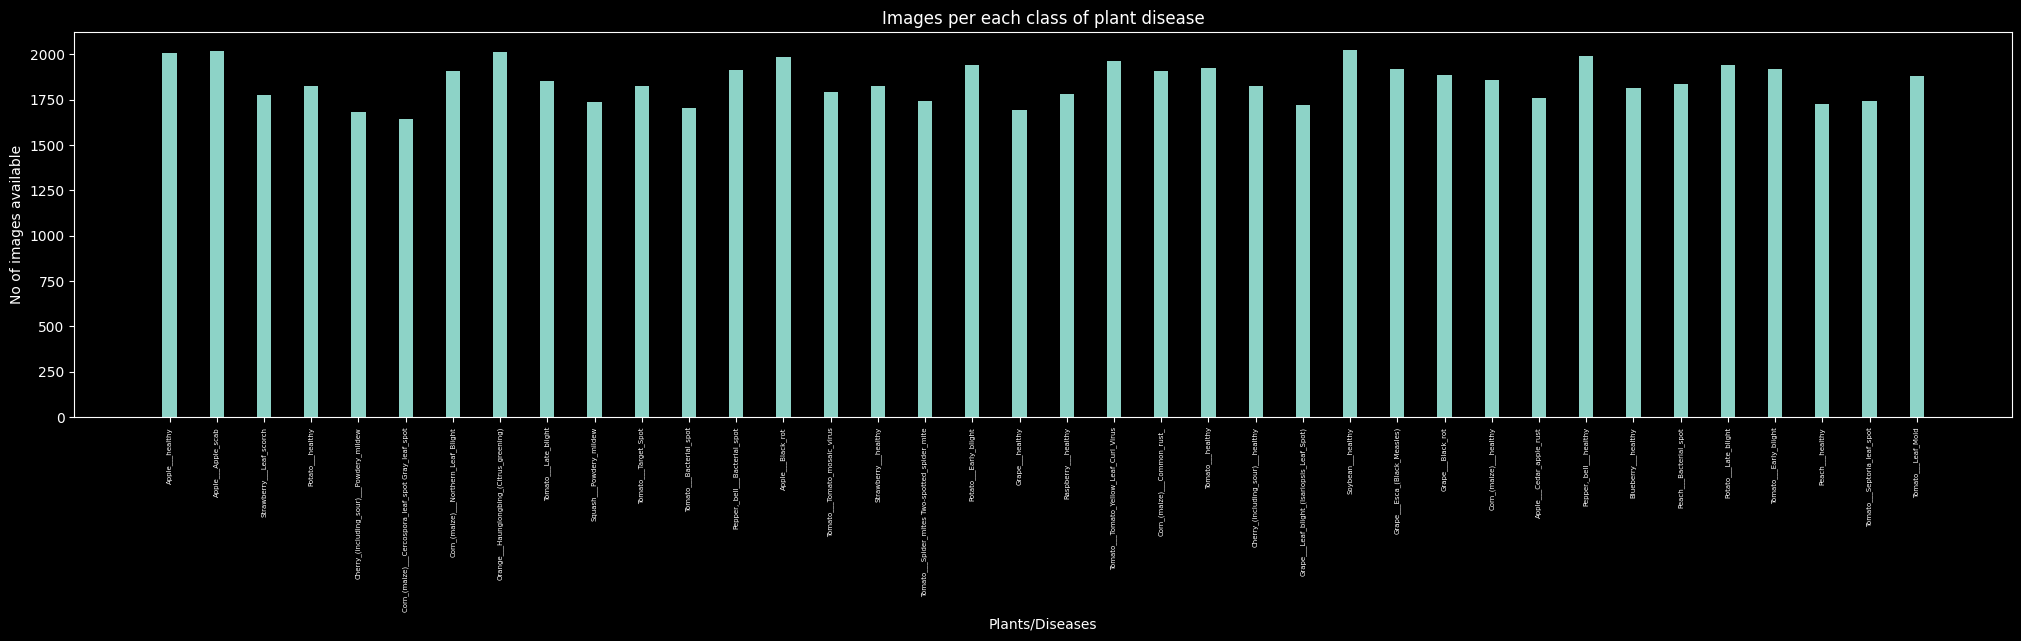

In [28]:
index = [n for n in range(38)]
plt.figure(figsize=(25, 5))
plt.bar(index, [n for n in nums.values()], width=0.3)
plt.xlabel('Plants/Diseases', fontsize=10)
plt.ylabel('No of images available', fontsize=10)
plt.xticks(index, diseases, fontsize=5, rotation=90)
plt.title('Images per each class of plant disease')

In [29]:
n_train = 0

for value in nums.values():
    n_train += value
print(f"There are {n_train} images for training")

There are 70295 images for training
